In [101]:
import pandas as pd
import yfinance as yf
import importlib
import helper
importlib.reload(helper)
from helper import *

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [102]:
ticker_list = ["AAPL", "MSFT", "GOOG"]

def get_history(tickers_list):
    df_list = []
    for i in tickers_list:
        curr_ticker = yf.Ticker(i)
        df = curr_ticker.history(start="2020-01-01", end="2024-12-31", interval="1d", auto_adjust=True)
        df["Ticker"] = i
        df.set_index(["Ticker", df.index], inplace=True)
        df_list.append(df)
    
    df = pd.concat(df_list, axis=0)
    return df

In [103]:
def build_features(h_df, spy_returns):
    merged_list = []

    for key, df in h_df.groupby(by="Ticker"):
        df = df.copy()

        add_returns(df)
        add_SMAs(df)
        add_rolling_volatility(df)
        add_volume(df)
        add_target_variable(df)

        dates = df.index.get_level_values("Date")
        df["SPY Daily Return"] = spy_returns.reindex(dates).values

        df.dropna(inplace=True)
        df.sort_index(inplace=True)

        merged_list.append(df)
    
    return pd.concat(merged_list)


In [104]:
def train_test_split(df):
    feature_cols = ["Daily Return", "5-day Lagged Return", "10-day Lagged Return",
                    "10day_SMA", "30day_SMA", "MA ratio", "rolling_vol", 
                    "10day Vol", "vol ratio", "SPY Daily Return"]
    label = "Target"

    X = df[feature_cols]
    y = df[label]

    X_train = X.loc[(slice(None), slice("2020-02-13", "2022-12-31")), :]
    X_test = X.loc[(slice(None), slice("2023-01-01", "2024-12-31")), :]
    y_train = y.loc[(slice(None), slice("2020-02-13", "2022-12-31"))]
    y_test = y.loc[(slice(None), slice("2023-01-01", "2024-12-31"))]

    return [X_train, X_test, y_train, y_test]

In [105]:
def preprocessing(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return [X_train_scaled, X_test_scaled, scaler]

In [106]:
def model_training(X_train_scaled, y_train):
    from sklearn.ensemble import RandomForestClassifier

    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
    fitted_model = rf_classifier.fit(X_train_scaled, y_train)

    return fitted_model

In [107]:
def inference(X_test_scaled, fitted_model):
    
    y_pred = fitted_model.predict_proba(X_test_scaled)[:, 1]
    
    return y_pred

In [108]:
# backtesting 
def backtesting(X_test, y_pred):
    X_test = X_test.copy()
    X_test["y_pred"] = y_pred  # assumes y_pred is in the same order as X_test rows

    merged_list = []

    for key, df in X_test.groupby(by="Ticker"):
        df = df.copy()
        add_strategy_return(df, df["y_pred"].values)
        add_cumulative_returns(df)

        df.dropna(inplace=True)
        df.sort_index(inplace=True)

        merged_list.append(df)
        
    X_test_returns = pd.concat(merged_list)
    return X_test_returns

In [109]:
def report(tickers_list, features_df, X_test_returns, y_test, y_pred):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(nrows=2, ncols=len(tickers_list), figsize=(6 * len(tickers_list), 10))

    j_test = X_test_returns.groupby(by="Ticker")
    j_full = features_df.groupby(by="Ticker")

    for counter, (key, test_item) in enumerate(j_test):
        full_item = j_full.get_group(key)
        visualize_results(full_item, test_item, counter, axes)

    plt.subplots_adjust(hspace=0.5)
    fig.suptitle("Visualization of data")
    plt.show()

    for ticker in tickers_list:
        mask = X_test_returns.index.get_level_values("Ticker") == ticker
        y_mask = y_test.index.get_level_values("Ticker") == ticker
        print(get_evaluation_metrics(ticker, X_test_returns[mask], y_test[y_mask], y_pred[y_mask]))

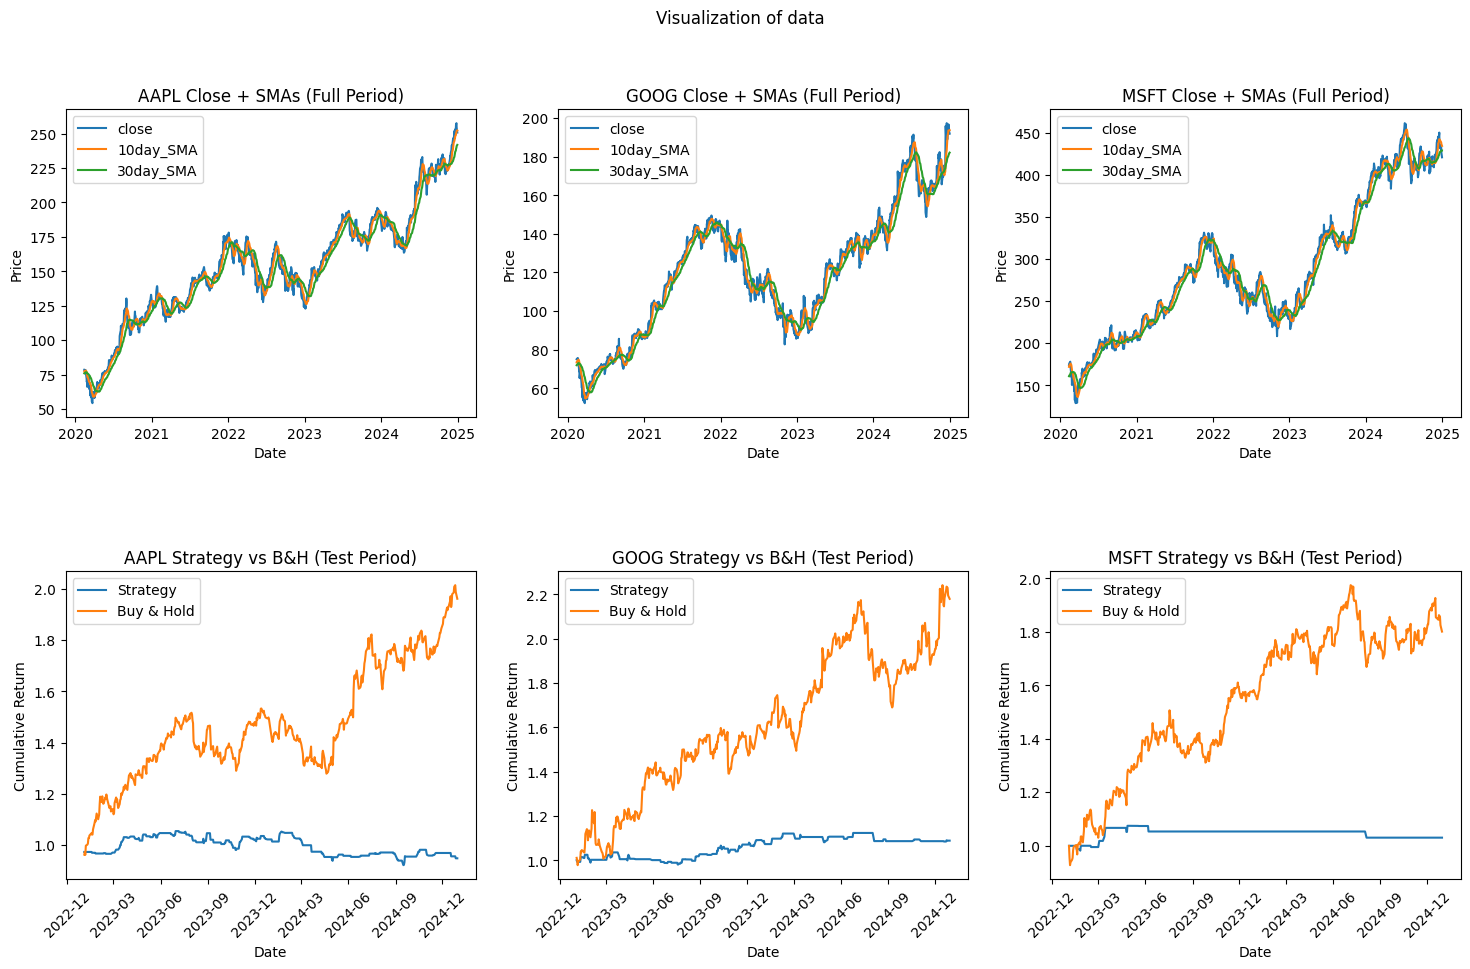

AAPL:
    Strategy Total return: -0.051742417537325114
    BH Total return: 0.9614569142740907
    Volatility: 0.2152345119183791
    Sharpe Ratio: 1.6825225908057144
    Model Accuracy: 0.5149700598802395
    Days in Market: 295
            
MSFT:
    Strategy Total return: 0.029868252926716687
    BH Total return: 0.8005250968518272
    Volatility: 0.22668993953421432
    Sharpe Ratio: 1.4186783176749709
    Model Accuracy: 0.47105788423153694
    Days in Market: 72
            
GOOG:
    Strategy Total return: 0.08855560353030745
    BH Total return: 1.1794472019186313
    Volatility: 0.2915966546184825
    Sharpe Ratio: 1.4905078736324098
    Model Accuracy: 0.48502994011976047
    Days in Market: 254
            


In [110]:
h_df = get_history(ticker_list)

spy_raw = yf.Ticker("SPY").history(start="2020-01-01", end="2024-12-31", interval="1d", auto_adjust=True)
spy_returns = spy_raw["Close"].pct_change()

features_df = build_features(h_df, spy_returns)
X_train, X_test, y_train, y_test = train_test_split(features_df)
X_train_scaled, X_test_scaled, scaler = preprocessing(X_train, X_test)
fitted_model = model_training(X_train_scaled, y_train)
y_pred = inference(X_test_scaled, fitted_model)
X_test_returns = backtesting(X_test, y_pred)
report(ticker_list, features_df, X_test_returns, y_test, y_pred)